João Pedro Jerônimo de Oliveira

# Lista prática I

**Instruções gerais:** Sua submissão deve conter: 
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynp

## Vizinhos mais próximos

**Exercício 1.** O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 5) e reporte a acurácia para cada valor de $k$. Lembre que a acurácia é o percentual de amostras classificadas corretamente. Notavelmente, as entradas do MNIST tem dimensão relativamente alta (64). Plote uma imagem com a variância amostral dos pixels das imagens e comente. Também mostre as imagens classificadas de maneira errônea e comente.

In [1]:
from dataclasses import dataclass

from typing import Callable, Any
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
import heapq


SEED = 42
np.random.seed(SEED)

@dataclass
class Dataset:
    features_train: np.ndarray 
    features_test: np.ndarray  
    labels_train: np.ndarray   
    labels_test: np.ndarray

# Import dataset and separate train/test subsets
mnist = Dataset(*train_test_split(
    *load_digits(return_X_y=True),
    random_state=SEED,
))

In [2]:
class KNN:
    def __init__(
        self,
        k: int,
        distance_function: Callable[[np.ndarray, np.ndarray], np.floating[Any]]
    ):
        """Initializes a KNN that can be used for regressions and classifications depending on the
        `distance_function` passed. 
    
        Parameters
        ----------
        k: int
            The amount of neighbors to consider when making a prediction
        distance_function: Callable[[np.ndarray, np.ndarray], np.floating[Any]]
            The function used to calculate the distance between two points
        """
        self.k = k
        self.distance_function = distance_function
        self.X = None
        self.t = None
        self.labels = None
    
    def fit(self, X: np.ndarray, t: np.ndarray):
        """Fits the KNN model to the given data. For KNN, this simply means storing the training data.

        Args:
            X (np.ndarray): The samples to fit
            t (np.ndarray): The labels of the training set
        """
        self.X = X
        self.t = t
        self.labels = np.unique(t)
    
    def predict(self, p: np.ndarray):
        """Predicts the label of a given point `p` based on the samples `X` and their
        labels `t` using the KNN algorithm.

        Args:
            X (np.ndarray): The samples to predict
            t (np.ndarray): The labels of the training set
            p (np.ndarray): The samples of the training set
        """
        if p.shape[-1] != self.X.shape[1]:
            raise ValueError("The given point does not have the required number of features")
        
        distances = []
        # Distance, Index, Label of the dataset point compared to the given point
    
        for j, sample in enumerate(self.X):
            distance = self.distance_function(sample, p)
            heapq.heappush(distances, (distance, j, self.t[j]))
        
        nearest_neighbors = heapq.nsmallest(self.k, distances)
        
        classification = np.zeros_like(self.labels, dtype=int)
        for nearest_neighbor in nearest_neighbors:
            classification[np.where(self.labels == nearest_neighbor[2])[0][0]] += 1
        return np.argmax(classification)

In [3]:
def euclidian_distance(x: np.ndarray, y: np.ndarray) -> np.floating[Any]:
    return np.sqrt(np.sum((x-y)**2))

In [4]:
ks = np.linspace(3, 13, 10, dtype=int)

predictions = np.zeros((len(ks), len(mnist.labels_test)))

for idx, k in enumerate(ks):
    knn = KNN(k=k, distance_function=euclidian_distance)
    knn.fit(mnist.features_train, mnist.labels_train)
    k_predictions = np.zeros_like(mnist.labels_test)
    for i, test_point in enumerate(mnist.features_test):
        k_predictions[i] = knn.predict(test_point)
    predictions[idx] = k_predictions

In [5]:
accuracies = np.zeros((len(ks),))
for idx, k in enumerate(ks):
    correct_predictions = np.sum(predictions[idx] == mnist.labels_test)
    accuracies[idx] = correct_predictions / len(mnist.labels_test)

In [6]:
print("KNN Accuracies:")
for idx, k in enumerate(ks):
    print(f"K={k}: {accuracies[idx]:.4f}")

KNN Accuracies:
K=3: 0.9867
K=4: 0.9867
K=5: 0.9933
K=6: 0.9956
K=7: 0.9933
K=8: 0.9889
K=9: 0.9867
K=10: 0.9867
K=11: 0.9800
K=13: 0.9800


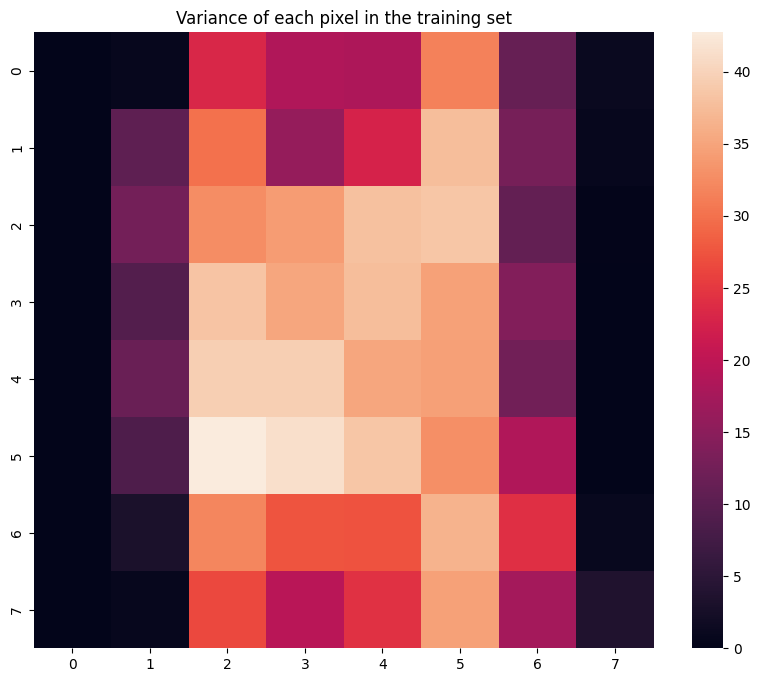

In [7]:
# Plotting the heatmap for the pixels in the images
vars = np.var(mnist.features_train, axis=0, ddof=1)
plt.figure(figsize=(10, 8))
sns.heatmap(vars.reshape(8, 8), fmt=".2f")
plt.title("Variance of each pixel in the training set")
plt.show()

Esse heatmap mostra como os números estão centralizados, realmente como imaginariamos que as imagens seriam. Além disso, a parte lateral mostra a parte vazia da imagem, totalmente branca

In [8]:
# Missclassified samples:
missclassified_indices = np.where(predictions[0] != mnist.labels_test)[0]

missclassified_samples = mnist.features_test[missclassified_indices]
missclassified_labels = mnist.labels_test[missclassified_indices]

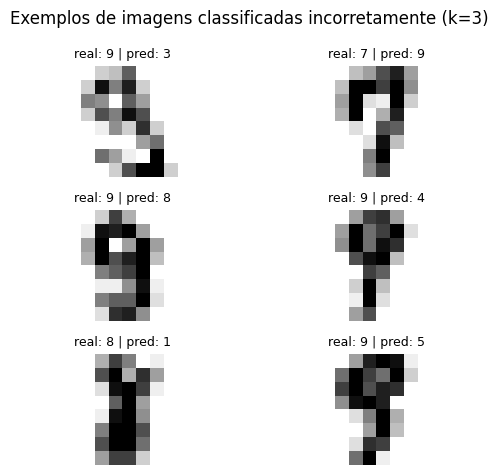

In [9]:
# Plot some misclassified images with true and predicted labels
n_to_show = min(16, len(missclassified_indices))
fig, axes = plt.subplots(3, 2)
axes = axes.ravel()

for i in range(n_to_show):
    idx_test = missclassified_indices[i]
    axes[i].imshow(mnist.features_test[idx_test].reshape(8, 8), cmap="gray_r")
    axes[i].set_title(
        f"real: {mnist.labels_test[idx_test]} | pred: {int(predictions[0][idx_test])}",
        fontsize=9
    )
    axes[i].axis("off")

# Hide any unused subplot panels
for i in range(n_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Exemplos de imagens classificadas incorretamente (k=3)")
plt.tight_layout()
plt.show()

É perceptível o porquê de ele ter errado algumas, como a inferior direita, e a central direita, que por mais que olhando parecem um nove, tão muito mal escritas e confusas, o mesmo vale para a inferior esquerda. Já as outras, elas parecem mais bem escritas, mas se prestarmos atenção, tem pixels levemente pintados de preto, esses pixels, se preenchermos, fazem com que se pareçam com números, e o KNN provavelmente interpretou dessa forma

**Exercício 02.** O código abaixo carrega o dataset "two moons", que consiste de amostras bidimensionais divididas em duas classes. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 10). Plote a superfície de decisão para cada valor de $k$. Como $k$ influencia na suavidade dessas superfícies?

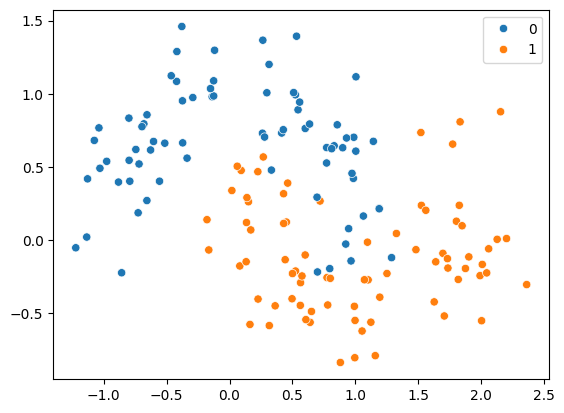

In [10]:
# Import dataset and separate train/test subsets
moon = Dataset(*train_test_split(
    *make_moons(n_samples=200, shuffle=True, noise=0.25, random_state=SEED),
    random_state=SEED,
))

# Let's also plot the moon dataset, for you to take a look at it.
sns.scatterplot(
    x=moon.features_train[:, 0],
    y=moon.features_train[:, 1],
    hue=moon.labels_train,
)
plt.show()

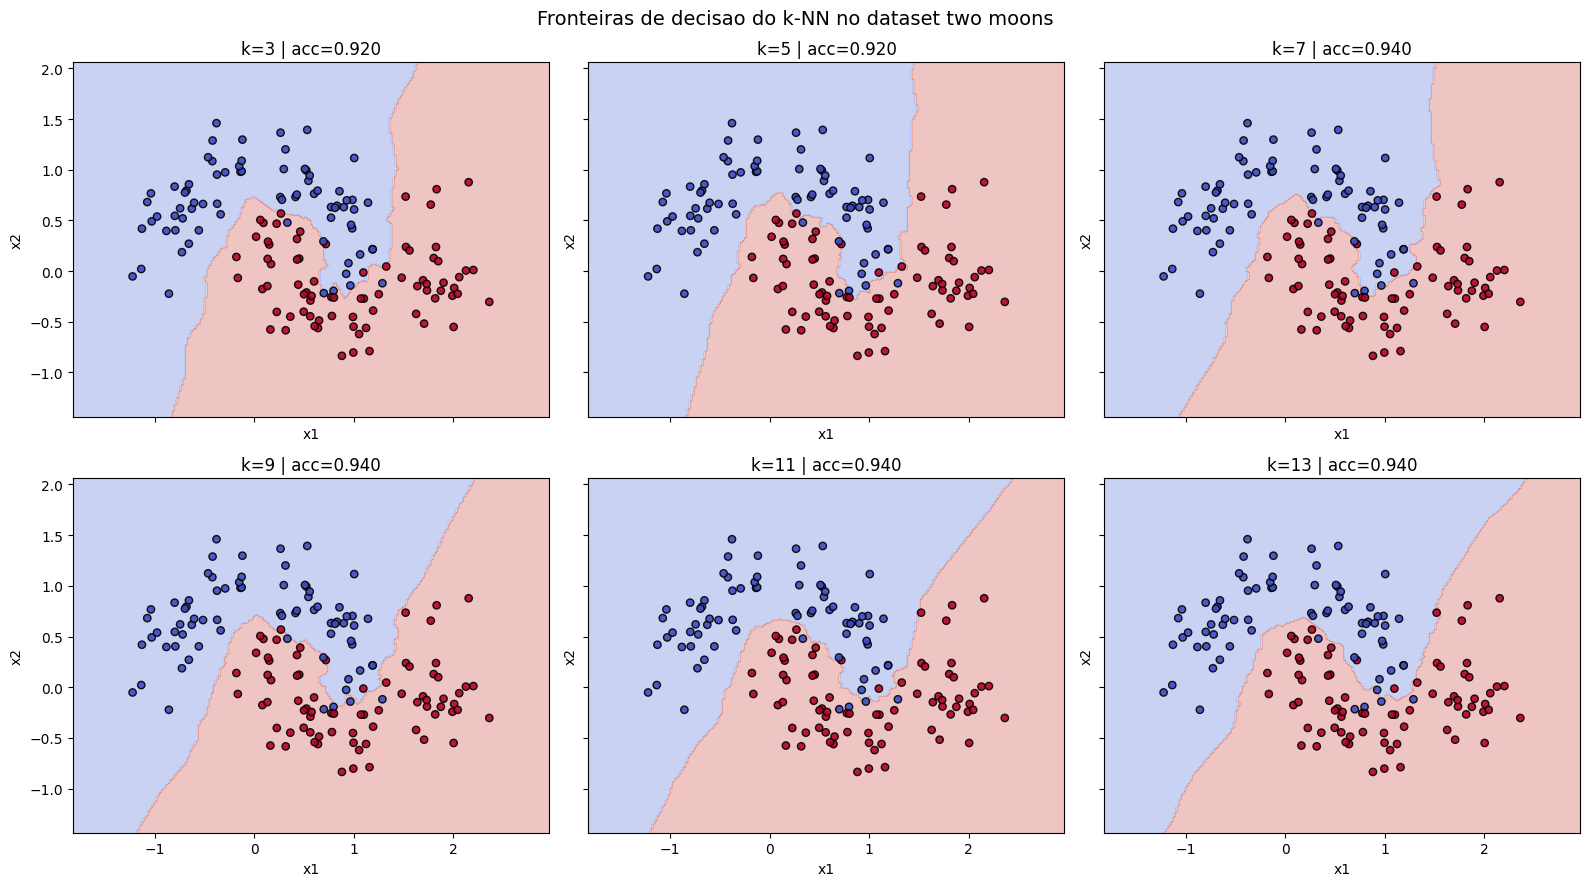

In [11]:
# Fronteiras de decisao para diferentes valores de k
ks = [3, 5, 7, 9, 11, 13]

# Limites do plano para desenhar a malha
x_min, x_max = moon.features_train[:, 0].min() - 0.6, moon.features_train[:, 0].max() + 0.6
y_min, y_max = moon.features_train[:, 1].min() - 0.6, moon.features_train[:, 1].max() + 0.6

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 220),
    np.linspace(y_min, y_max, 220),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

for idx, k in enumerate(ks):
    knn = KNN(k=k, distance_function=euclidian_distance)
    knn.fit(moon.features_train, moon.labels_train)

    # Predicao no conjunto de teste (acuracia)
    test_predictions = np.array([knn.predict(p) for p in moon.features_test])
    accuracy = np.mean(test_predictions == moon.labels_test)

    # Predicao na malha para desenhar a fronteira
    z = np.array([knn.predict(p) for p in grid_points]).reshape(xx.shape)

    ax = axes[idx]
    ax.contourf(xx, yy, z, alpha=0.30, cmap="coolwarm")
    ax.scatter(
        moon.features_train[:, 0],
        moon.features_train[:, 1],
        c=moon.labels_train,
        cmap="coolwarm",
        edgecolor="k",
        s=28,
        alpha=0.9,
    )
    ax.set_title(f"k={k} | acc={accuracy:.3f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.suptitle("Fronteiras de decisao do k-NN no dataset two moons", fontsize=14)
plt.tight_layout()
plt.show()

Podemos ver que, conforme o $k$ aumenta, a fronteira de decisão suaviza, ou seja, o modelo fica cada vez menos complexo

# Regressão linear

**Exercício 1.** Deixamos à sua disposição o dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing), dividio em treino, teste e validação.
O modelo que você utilizará para aproximar a relação funcional entre as features e as labels é o modelo linear, i.e., $\mathbf{y} = X\theta$.
Entretanto, você deve estimar seus parâmetros (minimizando o *mean squared error*) com **dois algoritmos diferentes**.
Uma implementação deve estimar $\theta$ por meio de **Stochastic Gradient Descent (SGD)** e, a outra, por meio de **Ordinary Least Squares (OLS)**, ou seja, utilizar a solução em fórmula fechada vista em aula.

Para o SGD, o ponto inicial deve ser escolhido aleatoriamente e o algoritmo deve parar quando a norma da diferença entre duas estimativas consecutivas de $\theta$ for menor do que um $\varepsilon > 0$ previamente especificado.
Para o experimento a seguir, fixe $\varepsilon$ em um valor pequeno (por exemplo, alguma potência de $1/10$) para a qual o algoritmo convirja no máximo em alguns minutos para uma solução com perda pequena.

Para diferentes tamanhos de minibatch (por exemplo $\{2^{j}: 1 \leq j \leq 7\}$), plote um gráfico representando o valor da perda $ L(\hat{\theta}) = \frac{1}{n} \lVert X \hat{\theta} - \mathbf{y} \rVert^{2}$ no conjunto de validação em função do número de epochs. Mostre também o valor ótimo obtido com OLS. Comente os resultados e o efeito tamanho do mini-batch, e.g., no tempo de treinamento. Reporte valores nos conjuntos de treino, validação e teste.

In [38]:
import numpy as np
from typing import Literal
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


SEED = 42
np.random.seed(SEED)


features, labels = fetch_california_housing(return_X_y=True)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25
)
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25
)

In [13]:
class LinearRegression:
    def __init__(self):
        self.theta = None
        self.X = None
        self.t = None

    def ols(self, c=1e-8):
        """Calculates the optimal parameters Theta using the Normal Equation."""
        return np.linalg.solve(self.X.T @ self.X + c * np.eye(self.X.shape[1]), self.X.T @ self.t)

    def sgd(self, learning_rate=0.01, n_iterations=1000, stop_threshold=1e-6, batch_size=32, max_norm=1.0):
        """Calculates the optimal parameters Theta using Stochastic Gradient Descent."""
        n, d = self.X.shape
        theta = np.random.normal(size=d)
        previous_theta = None
        for _ in range(n_iterations):
            previous_theta = theta.copy()
            for _ in range(batch_size):
                i = np.random.randint(n)
                xi = self.X[i:i+1]
                ti = self.t[i:i+1]
                gradients = 2/n * xi.T @ (xi @ theta - ti)

                norm = np.linalg.norm(gradients)
                if norm > max_norm:
                    gradients = gradients / norm * max_norm
                theta -= learning_rate * gradients.flatten()
                
            if np.linalg.norm(theta - previous_theta) < stop_threshold:
                return theta
        return theta

    def fit(
            self,
            X: np.ndarray,
            t: np.ndarray,
            mode: Literal['ols', 'sgd'] = 'ols',
            c=1e-8,
            lr=0.01,
            n_iterations=1000,
            stop_threshold=1e-6,
            batch_size=32,
            max_norm=1.0
        ):
        """Fits the Linear Regression model to the given data by calculating the optimal parameters Theta
        using the Normal Equation.

        Args:
            X (np.ndarray): The samples to fit
            t (np.ndarray): The labels of the training set
            mode (Literal['ols', 'sgd']): The method used to calculate the optimal parameters.
            'ols' for Ordinary Least Squares, 'sgd' for Stochastic Gradient Descent.
        """
        # Add bias term to the features
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        self.X = X_b
        self.t = t

        if mode == 'ols':
            self.theta = self.ols(c=c)
        elif mode == 'sgd':
            self.theta = self.sgd(
                learning_rate=lr,
                n_iterations=n_iterations,
                stop_threshold=stop_threshold,
                batch_size=batch_size,
                max_norm=max_norm
            )

In [14]:
def loss(X, t, theta):
    return np.mean((X @ theta - t) ** 2)

In [15]:
js = list(range(1,8))
batches_sizes = [2**j for j in js]

In [16]:
linear_regressions = [LinearRegression() for _ in batches_sizes]
lr_ols = LinearRegression()
lr_ols.fit(
    features_train,
    labels_train,
    mode='ols'
)
n_iterations = 10000
for i, lr in enumerate(linear_regressions):
    lr.fit(
        features_train,
        labels_train,
        mode='sgd',
        lr=0.001,
        n_iterations=n_iterations,
        stop_threshold=1e-6,
        batch_size=batches_sizes[i]
    )

Loss de validacao por tamanho de batch:
batch=  2 | SGD loss=762.093294 | OLS loss=0.535625
batch=  4 | SGD loss=45.826355 | OLS loss=0.535625
batch=  8 | SGD loss=136.844444 | OLS loss=0.535625
batch= 16 | SGD loss=135.561271 | OLS loss=0.535625
batch= 32 | SGD loss=424.507473 | OLS loss=0.535625
batch= 64 | SGD loss=90.612570 | OLS loss=0.535625
batch=128 | SGD loss=142.009788 | OLS loss=0.535625


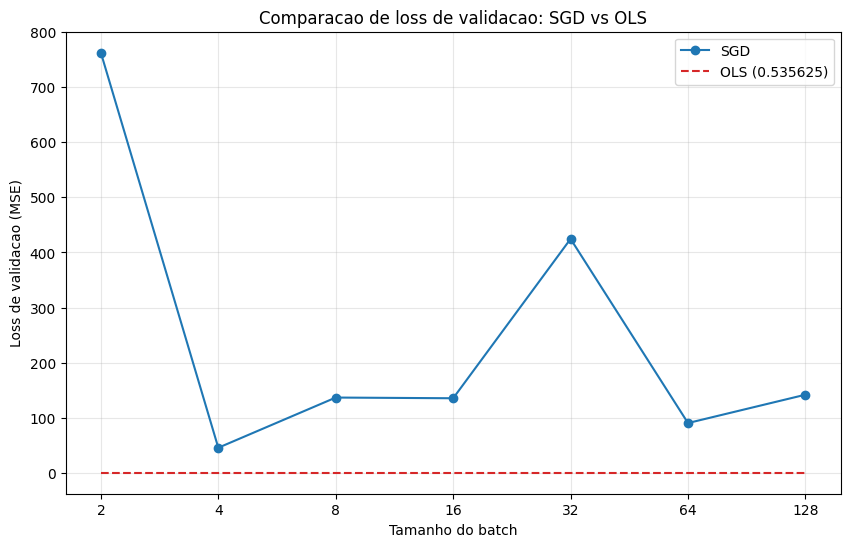

In [17]:
# Loss no conjunto de validacao para os modelos treinados
X_val_b = np.hstack([np.ones((features_validation.shape[0], 1)), features_validation])

validation_losses_sgd = []
validation_loss_ols = loss(X_val_b, labels_validation, lr_ols.theta)

print("Loss de validacao por tamanho de batch:")
for batch_size, reg_sgd in zip(batches_sizes, linear_regressions):
    val_loss_sgd = loss(X_val_b, labels_validation, reg_sgd.theta)
    validation_losses_sgd.append(val_loss_sgd)
    print(
        f"batch={batch_size:>3} | SGD loss={val_loss_sgd:.6f} | OLS loss={validation_loss_ols:.6f}"
    )

plt.figure(figsize=(10, 6))
plt.plot(batches_sizes, validation_losses_sgd, marker="o", label="SGD")
plt.hlines(
    y=validation_loss_ols,
    xmin=min(batches_sizes),
    xmax=max(batches_sizes),
    colors="tab:red",
    linestyles="--",
    label=f"OLS ({validation_loss_ols:.6f})",
)
plt.xscale("log", base=2)
plt.xticks(batches_sizes, batches_sizes)
plt.xlabel("Tamanho do batch")
plt.ylabel("Loss de validacao (MSE)")
plt.title("Comparacao de loss de validacao: SGD vs OLS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Exercício 2.** Agora, você deve implementar uma **Rede RBF** com função de base Gaussiana (veja as notas de aula).
Para os centróides, utilize o output de um modelo de clusterização por K médias, por meio da função que disponibilizamos, como a seguir:

In [18]:
def k_means_factory(n_clusters: int) -> KMeans:
    return KMeans(n_clusters=n_clusters, n_init="auto")

k_means_model = k_means_factory(n_clusters=2)
dumb_data = np.array(
    [[1, 2],
     [1, 4],
     [1, 0],
     [10, 2],
     [10, 4],
     [10, 0]]
)
k_means_model.fit(dumb_data)
cluster_centers = k_means_model.cluster_centers_
print(cluster_centers) # Shape (n_clusters, n_features)

[[10.  2.]
 [ 1.  2.]]


Para determinar o melhor valor de $k$ para o algoritmo de clusterização, treine o modelo (usando a fórmula de OLS) com diferentes valores e escolha o que possuir o menor erro de validação. Faça um gráfico mostrando o valor do erro de validação para diferentes valores de $k$. Mostre também a performance do modelo escolhido no conjunto de teste. Compare com o modelo linear simples da questão anterior. Discuta os resultados.

Para definir o valor do hiper-parâmetro $\gamma$, use a seguinte heurística --- que pode ser achado no livro "Neural Networks", por Simon Haykin:

$$
\gamma = \frac{1}{d_\text{max}^2},
$$

onde $d_\text{max}$ é a maior distância entre um par de centróides. Note que o valor costuma mudar para $k$'s diferentes.


In [31]:
def compute_gamma(centers: np.ndarray) -> float:
    M = centers.shape[0]
    d_max = 0.0
    for i in range(M):
        for j in range(i + 1, M):
            d = np.linalg.norm(centers[i] - centers[j])
            if d > d_max:
                d_max = d
    return 1.0 / (d_max ** 2) if d_max > 0 else 1.0

In [32]:
def rbf_transform(X: np.ndarray, centers: np.ndarray, gamma: float) -> np.ndarray:
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    sq_dist = np.sum(diff ** 2, axis=2)
    Z = np.exp(-gamma * sq_dist)
    return np.hstack([np.ones((Z.shape[0], 1)), Z])

In [33]:
def ols(Z: np.ndarray, t: np.ndarray, c: float = 1e-8) -> np.ndarray:
    return np.linalg.solve(Z.T @ Z + c * np.eye(Z.shape[1]), Z.T @ t)

In [39]:
X_train_b = np.hstack([np.ones((features_train.shape[0], 1)), features_train])
X_val_b   = np.hstack([np.ones((features_validation.shape[0], 1)), features_validation])
X_test_b  = np.hstack([np.ones((features_test.shape[0], 1)), features_test])
 
theta_linear     = ols(X_train_b, labels_train)
linear_val_loss  = loss(X_val_b,  labels_validation, theta_linear)
linear_test_loss = loss(X_test_b, labels_test,       theta_linear)
 
print(f"Linear OLS | val={linear_val_loss:.4f} | test={linear_test_loss:.4f}")

Linear OLS | val=0.5356 | test=0.5421


In [46]:
k_values   = list(range(1, 25))
val_losses = []
 
for k in k_values:
    km      = k_means_factory(k)
    km.fit(features_train)
    centers = km.cluster_centers_
    gamma   = compute_gamma(centers)
 
    Z_train = rbf_transform(features_train,      centers, gamma)
    Z_val   = rbf_transform(features_validation, centers, gamma)
 
    theta = ols(Z_train, labels_train)
    val_losses.append(loss(Z_val, labels_validation, theta))
 
best_k   = k_values[np.argmin(val_losses)]
best_val = min(val_losses)
print(f"\nMelhor k={best_k} | val MSE={best_val:.4f}")


Melhor k=23 | val MSE=1.3507


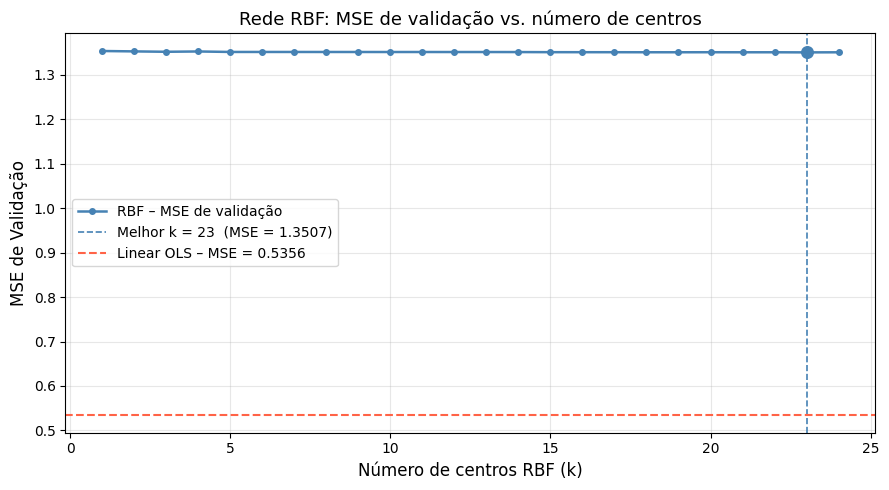

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
 
ax.plot(k_values, val_losses, marker='o', markersize=4, linewidth=1.8,
        color='steelblue', label='RBF – MSE de validação')
ax.axvline(best_k, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Melhor k = {best_k}  (MSE = {best_val:.4f})')
ax.scatter([best_k], [best_val], color='steelblue', zorder=5, s=70)
ax.axhline(linear_val_loss, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Linear OLS – MSE = {linear_val_loss:.4f}')
 
ax.set_xlabel('Número de centros RBF (k)', fontsize=12)
ax.set_ylabel('MSE de Validação', fontsize=12)
ax.set_title('Rede RBF: MSE de validação vs. número de centros', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

## Regressão logística

O pedaço de código abaixo carrega o banco de dados 'breast cancer' e adiciona uma coluna de bias. Além disse, ele o particiona em treino e teste.

1. Implemente a estimativa de máximo a posteriori para um modelo de regressão logística com priori $\mathcal{N}(0, c I)$ com $c=100$ usando esse banco de dados;
2. Implemente a aproximação de Laplace para o mesmo modelo;
3. Implemente uma aproximação variacional usando uma Gaussiana diagonal e o truque da reparametrização;
4. Calcule a accuracy no teste para todas as opções acima --- no caso das 2 últimas, a prob predita é $\int_\theta p(y|x, \theta) q(\theta)$;
5. Para cada uma das 3 técnicas, plote um gráfico com a distribuição das entropias para as predições corretas e erradas (separadamente), use a função kdeplot da biblioteca seaborn.
6. Comente os resultados, incluindo uma comparação dos gráficos das entropias.

Explique sua implementação também! 

Para (potencialmente) facilitar sua vida: use PyTorch, Adam como otimizador (é uma variação SGD) com lr=0.001, use o banco de treino inteiro ao invés de minibatchces, use binary_cross_entropy_with_logits para implementar a -log verossimilhança, use torch.autograd.functional para calcular a Hessiana. Você pode usar as bibliotecas importadas na primeira célula a vontade. Verifique a documentação de binary_cross_entropy_with_logits para garantir que a sua priori está implementada corretamente, preservando as proporções devidas. Use 10000 amostras das aproximações para calcular suas predições.

In [19]:
from sklearn.datasets import load_breast_cancer
import torch
import torch.nn.functional as F
from torch.autograd.functional import hessian

In [20]:
data =  load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N*0.6))
perm = np.random.permutation(len(data.data))
X = torch.tensor(data.data).float()
X = torch.cat((X, torch.ones((X.shape[0], 1))), axis=1) 
y = torch.tensor(data.target).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]

In [21]:
class LogisticRegression:
    def __init__(self):
        self.theta = None
        self.X = None
        self.t = None
        self.mode: Literal['maximum_posteriori', 'laplace']=None
        self.loss_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def maximum_posterirori(self, mean=None, covariance_matrix=None, epochs=10000, lr=0.01):
        n, d = self.X.shape
        theta = torch.randn(d, dtype=self.X.dtype, device=self.X.device, requires_grad=True)
        mean = torch.zeros(d, dtype=self.X.dtype, device=self.X.device) if mean is None else mean

        optimizer = torch.optim.SGD([theta], lr=lr)

        for _ in range(epochs):
            optimizer.zero_grad()

            # logits
            z = self.X @ theta

            # log-likelihood (negativa da BCE porque queremos maximizar)
            log_likelihood = -F.binary_cross_entropy_with_logits(z, self.t, reduction='sum')

            # log-prior gaussiano
            diff = theta - mean
            prior_term = -0.5 * diff @ torch.linalg.solve(covariance_matrix, diff)

            # log-posterior
            log_posterior = log_likelihood + prior_term

            # queremos maximizar → minimizar o negativo
            loss = -log_posterior
            loss.backward()

            self.loss_history.append(loss.item())

            optimizer.step()

        return theta.detach()
    
    def neg_log_posterior(self, theta, mean, covariance_matrix):
        z = self.X @ theta
        
        nll = F.binary_cross_entropy_with_logits(z, self.t, reduction='sum')
        
        diff = theta - mean
        prior = 0.5 * diff @ torch.linalg.solve(covariance_matrix, diff)
        
        return nll + prior

    def laplace(self, mean, covariance_matrix):
        theta_map = self.theta.clone().detach().requires_grad_(True)

        H = hessian(
            lambda th: self.neg_log_posterior(th, mean, covariance_matrix),
            theta_map
        )

        # regularização numérica (importante)
        eps = 1e-6
        H = H + eps * torch.eye(H.shape[0], device=H.device)

        cov = torch.linalg.inv(H)

        self.cov = cov
    
    def variational(self, mean, covariance_matrix, epochs=1000, lr=0.01, M=10):
        n, d = self.X.shape
        device = self.X.device
        dtype = self.X.dtype

        # parâmetros variacionais
        mu = torch.randn(d, dtype=dtype, device=device, requires_grad=True)
        rho = torch.zeros(d, dtype=dtype, device=device, requires_grad=True)  # log sigma

        optimizer = torch.optim.Adam([mu, rho], lr=lr)

        for _ in range(epochs):
            optimizer.zero_grad()

            sigma = torch.exp(rho)

            elbo = 0.0

            for _ in range(M):
                eps = torch.randn(d, dtype=dtype, device=device)
                theta = mu + sigma * eps  # reparametrização

                # log-likelihood
                z = self.X @ theta
                log_likelihood = -F.binary_cross_entropy_with_logits(z, self.t, reduction='sum')

                # log-prior
                diff = theta - mean
                log_prior = -0.5 * diff @ torch.linalg.solve(covariance_matrix, diff)

                # log q(theta)
                log_2pi = torch.log(torch.tensor(2 * torch.pi, dtype=dtype, device=device))
                log_q = -0.5 * torch.sum(((theta - mu) / sigma) ** 2 + 2 * rho + log_2pi)

                elbo += log_likelihood + log_prior - log_q

            elbo = elbo / M

            loss = -elbo
            loss.backward()
            self.loss_history.append(loss.item())
            optimizer.step()

        self.theta = mu.detach()
        self.sigma = torch.exp(rho).detach()
    
    def fit(
        self,
        X: torch.Tensor,
        t: torch.Tensor,
        mode: Literal['maximum_posteriori', 'laplace', 'variational']='maximum_posteriori',
        mean=None, covariance_matrix=None, epochs=10000, lr=0.01
    ):
        _, d = X.shape
        theta = torch.randn(d)
        self.mode = mode
        self.loss_history = []

        self.theta = theta
        self.X = X
        self.t = t

        if mode == 'maximum_posteriori':
            if covariance_matrix is None:
                raise ValueError("Covariance matrix must be provided for maximum posteriori mode.")
            if mean is None:
                mean = torch.zeros(d)
            
            # Getting argmax of the posteriori: log(p(D|theta)) + log(p(theta))
            self.theta = self.maximum_posterirori(
                mean=mean,
                covariance_matrix=covariance_matrix,
                epochs=epochs,
                lr=lr
            )

        elif mode == 'laplace':
            if covariance_matrix is None:
                raise ValueError("Covariance matrix must be provided for laplace mode.")
            if mean is None:
                mean = torch.zeros(d, dtype=X.dtype, device=X.device)

            self.theta = self.maximum_posterirori(
                mean=mean,
                covariance_matrix=covariance_matrix,
                epochs=epochs,
                lr=lr
            )

            self.laplace(mean, covariance_matrix)

        elif mode == 'variational':
            if covariance_matrix is None:
                raise ValueError("Covariance matrix must be provided.")
            if mean is None:
                mean = torch.zeros(d, dtype=X.dtype, device=X.device)

            self.variational(
                mean=mean,
                covariance_matrix=covariance_matrix,
                epochs=epochs,
                lr=lr
            )
    
    def predict_proba_laplace(self, X):
        probs = []

        for x in X:
            mu = x @ self.theta
            sigma2 = x @ self.cov @ x

            kappa = torch.sqrt(1 + (torch.pi / 8) * sigma2)
            prob = torch.sigmoid(mu / kappa)

            probs.append(prob)

        return torch.stack(probs)
    
    def predict_proba_variational(self, X, M=50):
        probs = []

        for x in X:
            samples = []

            for _ in range(M):
                eps = torch.randn_like(self.theta)
                theta_sample = self.theta + self.sigma * eps
                prob = torch.sigmoid(x @ theta_sample)
                samples.append(prob)

            probs.append(torch.mean(torch.stack(samples)))

        return torch.stack(probs)

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        if self.mode == 'laplace':
            probabilities = self.predict_proba_laplace(X)
        elif self.mode == 'maximum_posteriori':
            probabilities = self.sigmoid(X @ self.theta)
        elif self.mode == 'variational':
            probabilities = self.predict_proba_variational(X)
        return (probabilities >= 0.5).float()

In [22]:
logistic_regression_maximum_posteriori = LogisticRegression()
logistic_regression_laplace = LogisticRegression()
logistic_regression_variational = LogisticRegression()
c = 100
covariance_matrix = c*torch.eye(Xtrain.shape[1])
mean = torch.zeros(Xtrain.shape[1])

logistic_regression_maximum_posteriori.fit(
    Xtrain,
    ytrain,
    mode='maximum_posteriori',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

logistic_regression_laplace.fit(
    Xtrain,
    ytrain,
    mode='laplace',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

logistic_regression_variational.fit(
    Xtrain,
    ytrain,
    mode='variational',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

In [23]:
predictions_mp = logistic_regression_maximum_posteriori.predict(Xtest)
predictions_laplace = logistic_regression_laplace.predict(Xtest)
predictions_variational = logistic_regression_variational.predict(Xtest)

In [24]:
accuracy_mp = (predictions_mp == ytest).float().mean().item()
accuracy_laplace = (predictions_laplace == ytest).float().mean().item()
accuracy_variational = (predictions_variational == ytest).float().mean().item()

In [25]:
print(f"Accuracy (Maximum Posteriori): {accuracy_mp:.4f}")
print(f"Accuracy (Laplace): {accuracy_laplace:.4f}")
print(f"Accuracy (Variational): {accuracy_variational:.4f}")

Accuracy (Maximum Posteriori): 0.8855
Accuracy (Laplace): 0.8678
Accuracy (Variational): 0.9515


In [26]:
def entropy(p):
    eps = 1e-8  # evitar log(0)
    return -(p * torch.log(p + eps) + (1 - p) * torch.log(1 - p + eps))


def split_entropy(probs, y_true):
    preds = (probs >= 0.5).float()
    ent = entropy(probs)

    correct_mask = preds == y_true
    wrong_mask = preds != y_true

    return ent[correct_mask], ent[wrong_mask]

In [27]:
probs_mp = logistic_regression_maximum_posteriori.sigmoid(Xtest @ logistic_regression_maximum_posteriori.theta)
probs_laplace = logistic_regression_laplace.predict_proba_laplace(Xtest)
probs_variational = logistic_regression_variational.predict_proba_variational(Xtest)

In [28]:
ent_mp_correct, ent_mp_wrong = split_entropy(probs_mp, ytest)
ent_lap_correct, ent_lap_wrong = split_entropy(probs_laplace, ytest)
ent_var_correct, ent_var_wrong = split_entropy(probs_variational, ytest)

In [29]:
def plot_entropy(correct, wrong, title):
    plt.figure()
    
    sns.kdeplot(correct.numpy(), label='Correct', fill=True, alpha=0.4)
    sns.kdeplot(wrong.numpy(), label='Wrong', fill=True, alpha=0.4)
    
    plt.title(title)
    plt.xlabel("Entropy")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

C:\Users\Jotinha\AppData\Local\Temp\ipykernel_13328\2848835438.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(correct.numpy(), label='Correct', fill=True, alpha=0.4)
C:\Users\Jotinha\AppData\Local\Temp\ipykernel_13328\2848835438.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(wrong.numpy(), label='Wrong', fill=True, alpha=0.4)
C:\Users\Jotinha\AppData\Local\Temp\ipykernel_13328\2848835438.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


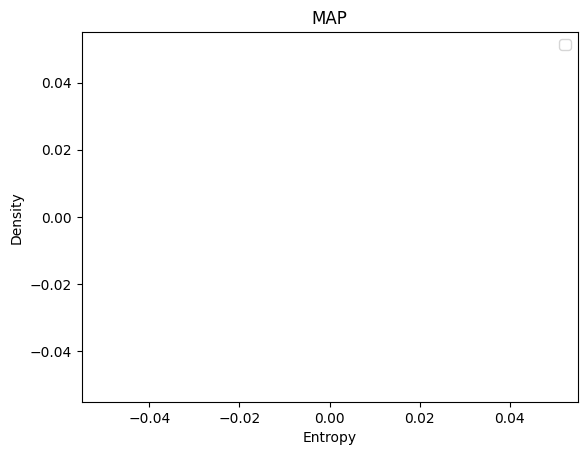

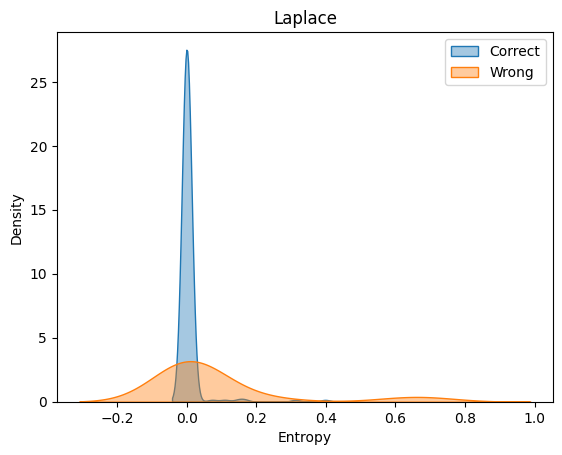

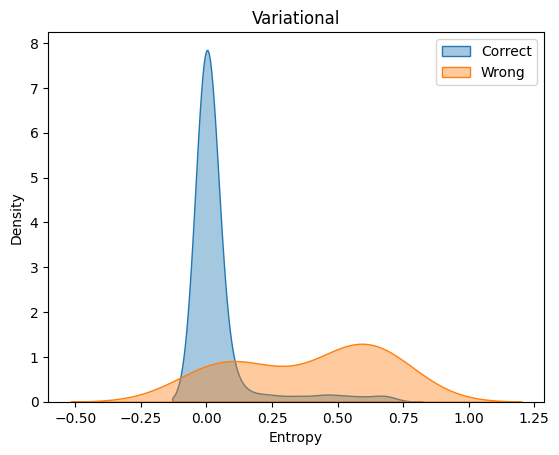

In [30]:
plot_entropy(ent_mp_correct, ent_mp_wrong, "MAP")
plot_entropy(ent_lap_correct, ent_lap_wrong, "Laplace")
plot_entropy(ent_var_correct, ent_var_wrong, "Variational")